Import required libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold

Path to the MovieLens ratings file

In [3]:
data_path = "/ratings.csv"
n_users = 6040
n_movies = 3706

Load Rating Data

In [15]:
def load_rating_data(data_path):
    ratings = []
    user_ids = set()
    movie_ids = set()

    with open(data_path, "r", encoding="utf-8") as file:
        header = file.readline()  # رد شدن از خط اول

        for line in file:
            line = line.strip()
            if not line:
                continue

            user_id, movie_id, rating, timestamp = line.split(",")

            user_id = int(user_id)
            movie_id = int(movie_id)
            rating = float(rating)

            user_ids.add(user_id)
            movie_ids.add(movie_id)
            ratings.append((user_id, movie_id, rating))

    user_id_mapping = {user_id: i for i, user_id in enumerate(sorted(user_ids))}
    movie_id_mapping = {movie_id: i for i, movie_id in enumerate(sorted(movie_ids))}

    n_users = len(user_id_mapping)
    n_movies = len(movie_id_mapping)

    data = np.zeros((n_users, n_movies), dtype=np.float32)
    movie_n_rating = defaultdict(int)

    for user_id, movie_id, rating in ratings:
        user_index = user_id_mapping[user_id]
        movie_index = movie_id_mapping[movie_id]

        data[user_index, movie_index] = rating

        if rating > 0:
            movie_n_rating[movie_id] += 1

    return data, movie_n_rating, movie_id_mapping, user_id_mapping

Load the dataset into memory

In [5]:
data, movie_n_rating, movie_id_mapping, user_id_mapping = load_rating_data(data_path)

Inspect Rating Distribution

In [ ]:
def display_distribution(data):
    values, counts = np.unique(data, return_counts=True)
    for value, counts in zip(values, counts):
        print(f"Number of rating {int(value)}:{counts}")

#Show rating distribution for the whole user-movie matrix
display_distribution(data)

Number of rating 0:5830804
Number of rating 0:1370
Number of rating 1:2811
Number of rating 1:1791
Number of rating 2:7551
Number of rating 2:5550
Number of rating 3:20047
Number of rating 3:13136
Number of rating 4:26818
Number of rating 4:8551
Number of rating 5:13211


Select the Target Movie

In [7]:
movie_id_most, n_rating_most = sorted(movie_n_rating.items(), key=lambda d: d[1], reverse=True) [0]
print(f"Movie ID {movie_id_most} has {n_rating_most} ratings.") 

Movie ID 356 has 329 ratings.


Prepare Features and Labels

In [8]:
X_raw = np.delete(data, movie_id_mapping[movie_id_most], axis=1)
Y_raw = data[:, movie_id_mapping[movie_id_most]]

X = X_raw[Y_raw > 0]
Y = Y_raw[Y_raw > 0]
print("Shape of X:", X.shape)
print("Shape of Y:", Y.shape)
display_distribution(Y)

Shape of X: (329, 9723)
Shape of Y: (329,)
Number of rating 0:1
Number of rating 1:1
Number of rating 2:9
Number of rating 2:3
Number of rating 3:39
Number of rating 3:27
Number of rating 4:94
Number of rating 4:39
Number of rating 5:116


Convert Ratings to Binary Labels

In [9]:
recommend = 3
Y[Y <= recommend] = 0
Y[Y > recommend] = 1
n_pos = (Y == 1).sum()
n_neg = (Y == 0).sum()

print(f"{n_pos} positive samples and {n_neg} negative samples.")

276 positive samples and 53 negative samples.


Split Data into Train and Test Sets

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(len(Y_train), len(Y_test))

263 66


Train Multinomial Naive Bayes

In [11]:
clf = MultinomialNB(alpha=1.0, fit_prior=True)
clf.fit(X_train, Y_train)
prediction_prob = clf.predict_proba(X_test)
print(prediction_prob[0:10])

prediction = clf.predict(X_test)
print(prediction[:10])

accuracy = clf.score(X_test, Y_test)
print(f"The accuracy is: {accuracy*100:.1f}%")

[[2.51868335e-058 1.00000000e+000]
 [9.41466882e-045 1.00000000e+000]
 [2.53204669e-102 1.00000000e+000]
 [6.89190503e-013 1.00000000e+000]
 [5.31573361e-014 1.00000000e+000]
 [7.35832927e-001 2.64167073e-001]
 [2.60342830e-023 1.00000000e+000]
 [4.47896831e-114 1.00000000e+000]
 [3.25736320e-036 1.00000000e+000]
 [1.55745365e-059 1.00000000e+000]]
[1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
The accuracy is: 78.8%


In [12]:
print(confusion_matrix(Y_test, prediction, labels=[0, 1]))

[[ 2  9]
 [ 5 50]]


In [13]:
report = classification_report(Y_test, prediction)
print(report)

              precision    recall  f1-score   support

         0.0       0.29      0.18      0.22        11
         1.0       0.85      0.91      0.88        55

    accuracy                           0.79        66
   macro avg       0.57      0.55      0.55        66
weighted avg       0.75      0.79      0.77        66



In [16]:
# Probability of the positive class
pos_prob = prediction_prob[:, 1]

# Thresholds for ROC curve calculation
thresholds = np.arange(0.0, 1.1, 0.05)

# Initialize True Positive and False Positive counters
true_pos = [0] * len(thresholds)
false_pos = [0] * len(thresholds)

# Count TP and FP for each threshold
for pred, y in zip(pos_prob, Y_test):
    for i, threshold in enumerate(thresholds):
        # If the predicted probability is greater than or equal to the threshold,
        # the sample is considered positive.
        if pred >= threshold:
            if y == 1:
                # True Positive: actual label is 1 and predicted label is also 1
                true_pos[i] += 1
            else:
                # False Positive: actual label is 0 but predicted label is 1
                false_pos[i] += 1
        else:
            # Since thresholds are increasing,
            # larger thresholds will also be greater than pred.
            break

# Number of positive and negative samples in the test set
n_pos_test = int((Y_test == 1).sum())
n_neg_test = int((Y_test == 0).sum())

# Compute True Positive Rate and False Positive Rate
# Add a small guard to avoid division by zero
true_pos_rate = np.array([
    tp / n_pos_test if n_pos_test > 0 else 0.0
    for tp in true_pos
])

false_pos_rate = np.array([
    fp / n_neg_test if n_neg_test > 0 else 0.0
    for fp in false_pos
])

# The thresholds are increasing, so ROC points are generated from (1,1) toward (0,0).
# Reverse them to plot the ROC curve in the usual direction.
true_pos_rate = true_pos_rate[::-1]
false_pos_rate = false_pos_rate[::-1]

Plot ROC Curve

C:\Users\Benyamin\AppData\Local\Temp\ipykernel_3212\4243235233.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


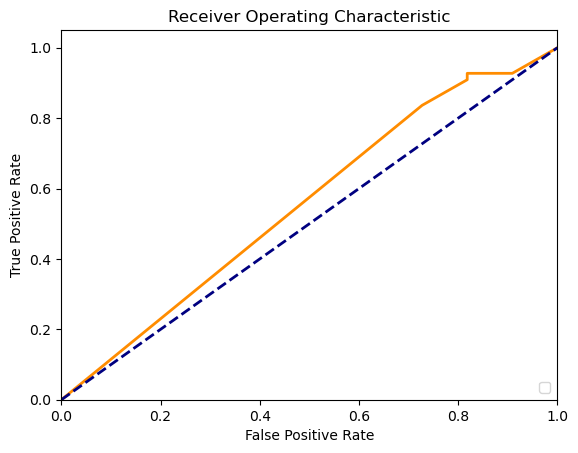

0.5586776859504131


In [17]:
plt.figure()
lw = 2
plt.plot(false_pos_rate, true_pos_rate, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(roc_auc_score(Y_test, pos_prob))

Hyperparameter Search Using Grouped Cross-Validation

In [ ]:
# Hyperparameter search using grouped stratified k-fold cross-validation
k = 5
# random_state is only effective when shuffle=True
k_fold = StratifiedGroupKFold(
    n_splits=k,
    shuffle=True,
    random_state=42
)

# Hyperparameter options
smoothing_factor_options = [1, 2, 3, 4, 5, 6]
fit_prior_options = [True, False]

# Dictionary to store AUC values for each hyperparameter combination
auc_record = {}

# Number of valid folds that contain both classes
valid_folds = 0

# groups should have the same length as X and Y.
# If you want to group by users, create this variable before this cell:
user_indices = np.where(Y_raw > 0)[0]
groups = user_indices

for train_indices, test_indices in k_fold.split(X, Y, groups=groups):
    X_train_fold = X[train_indices]
    X_test_fold = X[test_indices]

    Y_train_fold = Y[train_indices]
    Y_test_fold = Y[test_indices]

    # ROC AUC needs both positive and negative classes in the validation fold.
    if len(np.unique(Y_test_fold)) < 2:
        continue

    valid_folds += 1

    for alpha in smoothing_factor_options:
        if alpha not in auc_record:
            auc_record[alpha] = {}

        for fit_prior in fit_prior_options:
            clf = MultinomialNB(
                alpha=alpha,
                fit_prior=fit_prior
            )

            clf.fit(X_train_fold, Y_train_fold)

            prediction_prob = clf.predict_proba(X_test_fold)
            pos_prob = prediction_prob[:, 1]

            auc = roc_auc_score(Y_test_fold, pos_prob)

            # Accumulate AUC values across folds
            auc_record[alpha][fit_prior] = (
                auc + auc_record[alpha].get(fit_prior, 0.0)
            )

In [23]:
for smoothelong, smoothelong_record in auc_record.items():
    for fit_prior, auc in smoothelong_record.items():
        print(f' {smoothelong} {fit_prior} {auc/k:.5f}')

 1 True 0.57885
 1 False 0.58594
 2 True 0.59784
 2 False 0.60165
 3 True 0.56975
 3 False 0.56839
 4 True 0.54652
 4 False 0.54652
 5 True 0.54122
 5 False 0.54122
 6 True 0.53547
 6 False 0.53391


In [24]:
clf = MultinomialNB(alpha=2.0, fit_prior=False)
clf.fit(X_train, Y_train)
pos_prob = clf.predict_proba(X_test)[:, 1]
print('AUC with the best model:', roc_auc_score(Y_test, pos_prob))

AUC with the best model: 0.5206611570247934
